# 09 · Coherence: $T_1$ of |1⟩ and |2⟩, Ramsey fringes and the 1–2 frequency

The incoherent half of the error budget. Two things were measured repeatedly:

* **Ramsey fringes** on 0–1 and on 1–2 with a deliberately detuned drive — in 2024 to pin the transition frequencies
  (`characterization/ramseyv0_*`, `ibm_brisbane` q1 and q109) and in 2025 to get $T_2^*$ of the 1–2 coherence (`characterization/ramsey`, q109);
* **$T_1$** of |1⟩ and of |2⟩ with one experiment each (`characterization/T1`, Jan 2025), fitted with the three-level rate equations
  |2⟩ → |1⟩ → |0⟩ (`simulation.three_level_decay`; `full_transmon.ipynb` did the same with a QuTiP master equation).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from pulseshop import readout, io, fitting, simulation as sim, constants as C
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
dt_ns = C.dt / C.ns

## 1. Ramsey fringes of 2024: finding $f_{01}$ and $f_{12}$ precisely

SX, delay, SX with the drive detuned by Δ from the backend estimate; the fringe frequency equals the true detuning, so its difference
from Δ is the frequency error. Delays 8 … 2000 dt in steps of 8 dt (4 ns … 1 µs), averaged readout.

0-1, q1    detuning  3.0 MHz -> measured fringe 3.012 MHz -> frequency error +0.012 MHz
0-1, q1    detuning 10.0 MHz -> measured fringe 10.040 MHz -> frequency error +0.040 MHz
1-2, q109  detuning  3.0 MHz -> measured fringe 4.016 MHz -> frequency error +1.016 MHz
1-2, q109  detuning 10.0 MHz -> measured fringe 11.044 MHz -> frequency error +1.044 MHz


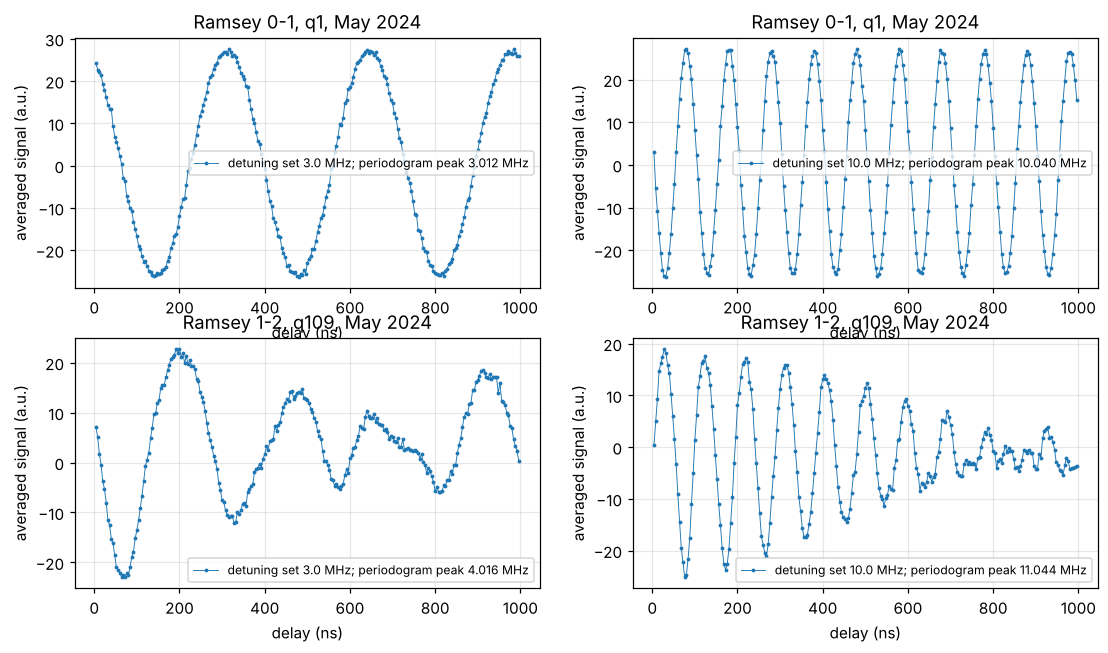

In [2]:
delays_ns = np.arange(8, 2000, 8) * dt_ns
runs = [("ramseyv0_01", 1, "0-1, q1", "round1", 3.0), ("ramseyv0_01", 2, "0-1, q1", "round2", 10.0),
        ("ramseyv0_12", 1, "1-2, q109", "round1", 3.0), ("ramseyv0_12", 2, "1-2, q109", "round2", 10.0)]
fig, axes = plt.subplots(2, 2, figsize=(12, 6.5))
for ax, (folder, rnd, lab, fname, det) in zip(axes.ravel(), runs):
    y = io.load_npy(f"shop_2024/characterization/{folder}/data", f"{fname}.npy")
    t = delays_ns[: len(y)]
    f_dom, f, pxx = fitting.dominant_frequency(t / 1e3, y)      # t in us -> f in MHz
    ax.plot(t, y, ".-", ms=3, lw=0.6, label=f"detuning set {det} MHz; periodogram peak {f_dom:.3f} MHz")
    ax.set(xlabel="delay (ns)", ylabel="averaged signal (a.u.)", title=f"Ramsey {lab}, May 2024"); ax.legend(fontsize=8)
    print(f"{lab:10s} detuning {det:4.1f} MHz -> measured fringe {f_dom:.3f} MHz -> frequency error {f_dom - det:+.3f} MHz")
io.save_fig(fig, "09_ramsey_2024_frequency")

The 0–1 fringes come out within a few tens of kHz of the set detuning: the backend's $f_{01}$ is good. The 1–2 fringes are 1.0 MHz off:
the backend's $f_{01} + \alpha$ estimate of the 1–2 frequency was wrong by that much and was corrected (the `freq` in `sx12_params.json`).
They also beat (the 2024 notebook fitted a two-cosine model) — the signature of the charge dispersion of the 1–2 transition, which for this
low-$E_J/E_C$ qubit ($E_J/E_C \approx 37$, notebook 11) is of the order of 0.1–1 MHz and makes $f_{12}$ jump between two values on the time
scale of quasiparticle tunnelling. This is one reason the paper's 1–2 pulses are only 20 ns long: a short pulse is broadband enough to cover both.

## 2. Ramsey on 1–2 in 2025: $T_2^*$ of the 1–2 coherence

X, SX12, delay, SX12, X with 20 ns pulses, delays 4 ns … 100 µs (250 points), 5 000 shots, averaged kerneled IQ (the 2025 analysis also used periodograms).

cyfv8xb01rbg008fhvx0 detuning 1.0 MHz: fringe 0.986 MHz, T2* = 38.4 us
cyfq51wcw2k00088wv4g detuning 0.5 MHz: two strongest components at 0.57 and 0.27 MHz (beating, no single-fringe fit)
cyfv8na01rbg008fhvw0 detuning 0.1 MHz: two strongest components at 0.32 and 0.15 MHz (beating, no single-fringe fit)


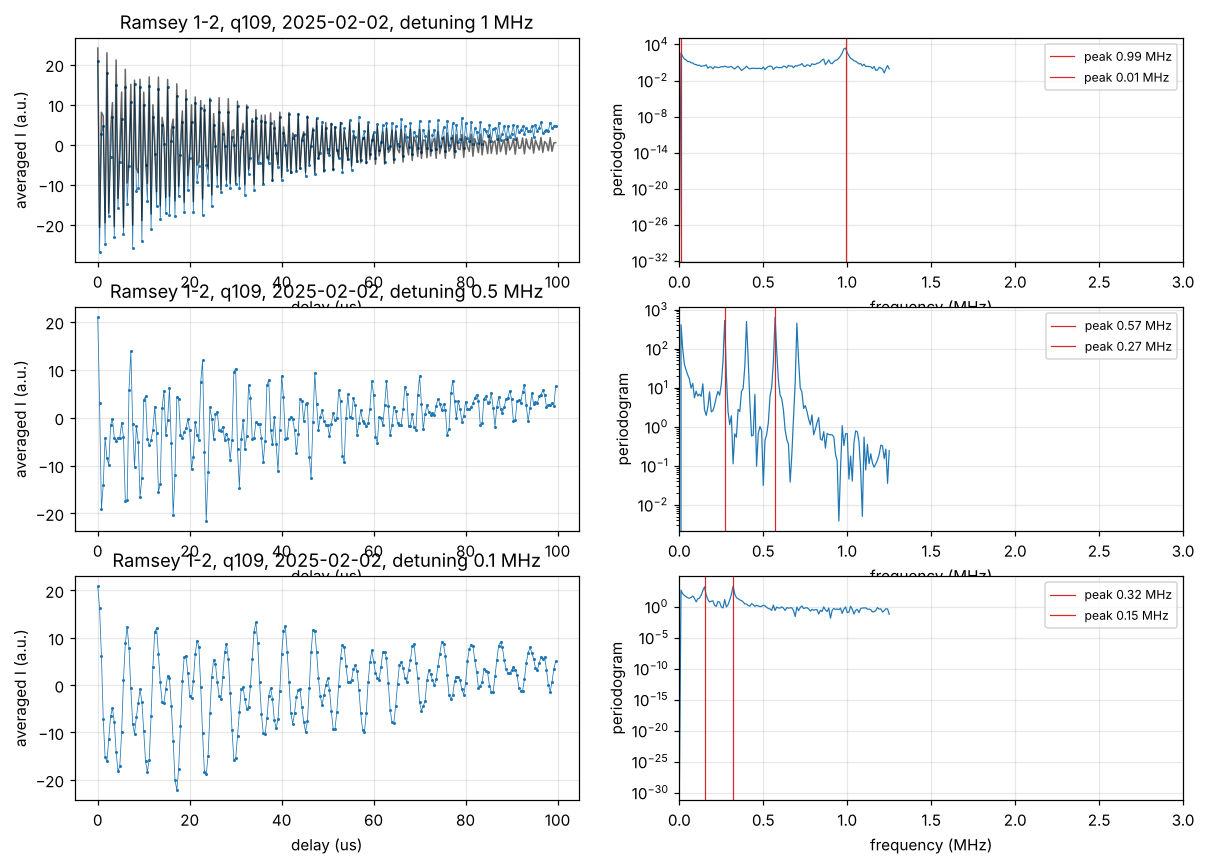

In [3]:
jobs = [("cyfv8xb01rbg008fhvx0", "1 MHz"), ("cyfq51wcw2k00088wv4g", "0.5 MHz"), ("cyfv8na01rbg008fhvw0", "0.1 MHz")]
fig, axes = plt.subplots(3, 2, figsize=(13, 9))
for row, (job, lab) in zip(axes, jobs):
    iq, prm = io.load_job(f"pending_2025/characterization/ramsey/data/{job}")
    t_us = np.array(prm["delay_time_dt"]) * dt_ns / 1e3
    y = np.real(iq.mean(axis=1))
    det = prm["detuning_MHz"]
    row[0].plot(t_us, y, ".-", ms=2, lw=0.5)
    f_dom, f, pxx = fitting.dominant_frequency(t_us, y)
    # the two strongest periodogram components (the 1-2 line is a doublet)
    order = np.argsort(pxx[1:])[::-1] + 1
    peaks = [f[order[0]]]
    for i in order[1:]:
        if abs(f[i] - peaks[0]) > 0.08:
            peaks.append(f[i]); break
    if det >= 1.0:
        pars, yfit, _ = fitting.fit_function(t_us, y, fitting.damped_cosine, [(y.max() - y.min()) / 2, y.mean(), 1 / det, 0, 20])
        row[0].plot(t_us, yfit, "-", lw=1, color="k", alpha=0.6)
        print(f"{job} detuning {det} MHz: fringe {1/abs(pars[2]):.3f} MHz, T2* = {abs(pars[4]):.1f} us")
    else:
        print(f"{job} detuning {det} MHz: two strongest components at {peaks[0]:.2f} and {peaks[1]:.2f} MHz (beating, no single-fringe fit)")
    row[1].semilogy(f, pxx, lw=0.8)
    for pk in peaks:
        row[1].axvline(pk, color="C3", lw=0.8, label=f"peak {pk:.2f} MHz")
    row[0].set(xlabel="delay (us)", ylabel="averaged I (a.u.)", title=f"Ramsey 1-2, q109, {prm['datetime'][:10]}, detuning {lab}")
    row[1].set(xlabel="frequency (MHz)", ylabel="periodogram", xlim=(0, 3)); row[1].legend(fontsize=8)
io.save_fig(fig, "09_ramsey12_2025_T2star")

At 1 MHz detuning the fringe decays with $T_2^* \approx 40$ µs — long compared with a 20 ns gate. The 0.5 and 0.1 MHz runs show the beating
that the 2024 data already hinted at: two components 0.2–0.3 MHz apart, i.e. the 1–2 frequency is not a single number (the charge-dispersion
doublet). The experiment_ids notebook of the paper logs these runs as attempts "to observe the peaks caused by dephasing".

## 3. $T_1$ of |1⟩ and |2⟩ (Jan 2025)

Job `cy5we10…`: X then a delay; job `cy5wyv3…`: X, X12 then the delay. 100 log-spaced delays from 4 ns to 360 µs, nearest-centre
discriminator and the confusion matrix of the day (notebook 02). The IBM-reported $T_1$ of the qubit was 90 µs.

In [4]:
centres = io.load_npy("pending_2025", "central_clusters.npy")
cd = readout.CentroidDiscriminator(centres)
cm = io.load_npy("pending_2025", "confusion_matrix.npy")
delay_us = io.load_npy("pending_2025/characterization/T1", "delay_time_mu.npy")
t1_runs = {}
for job, lab in [("cy5we10rta1g00873a50", "X then delay"), ("cy5wyv301rbg008j6grg", "X, X12 then delay")]:
    iq, prm = io.load_job(f"pending_2025/characterization/T1/data/{job}")
    raw = readout.count(iq, cd)
    t1_runs[lab] = (raw, readout.mitigate(raw, cm))
# cross-check with the populations saved by the original notebook
saved = np.array([io.load_npy("pending_2025/characterization/T1", f"pop{k}_t1_012.npy") for k in range(3)]).T
print("max |difference| between the re-derived and the saved mitigated populations of the X, X12 run:", np.abs(t1_runs["X, X12 then delay"][1] - saved).max().round(3))

max |difference| between the re-derived and the saved mitigated populations of the X, X12 run: 0.028


Fit: |1⟩ run → single exponential; |2⟩ run → three-level rate equations with the decay rates $\gamma_{21}, \gamma_{10}, \gamma_{20}$ as free
parameters (the 2025 notebook fitted the same chain by running a QuTiP master equation inside the optimiser and found
$\gamma_{21} = 6.67\times10^{-6}$, $\gamma_{10} = 6.06\times10^{-6}$, $\gamma_{20} = 4.2\times10^{-7}$ per ns).

|1> run: T1(|1>) = 78.2 us (single exponential with free offset; IBM reported 90 us that day)
|2> run: gamma_21 = 5.89e-06/ns, gamma_10 = 6.08e-06/ns, gamma_20 = 5.60e-07/ns
         T1(|2>) = 1/(gamma_21+gamma_20) = 155.0 us,  T1(|1>) from this run = 164.4 us


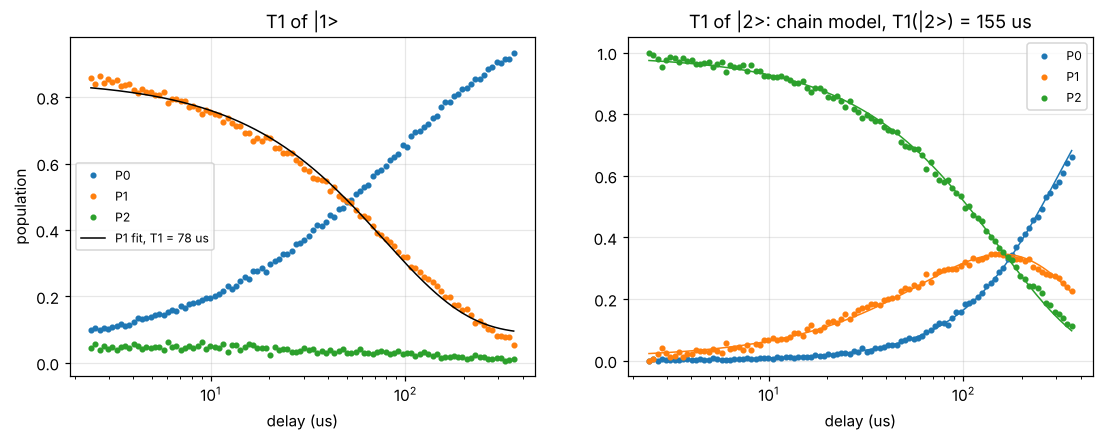

In [5]:
raw1, pop1 = t1_runs["X then delay"]
pars1, yfit1, _ = fitting.fit_function(delay_us, pop1[:, 1], fitting.exp_decay, [1, 90, 0])
print(f"|1> run: T1(|1>) = {pars1[1]:.1f} us (single exponential with free offset; IBM reported 90 us that day)")

raw2, pop2 = t1_runs["X, X12 then delay"]

def chain(t, g21, g10, g20, p2_0, p1_0):
    return sim.three_level_decay(t, g21, g10, g20, p2_0, p1_0).ravel()

p0 = [1 / 150, 1 / 90, 1e-4, 0.85, 0.1]
pars2, _ = curve_fit(chain, delay_us, pop2.ravel(), p0, bounds=([0, 0, 0, 0, 0], [1, 1, 1, 1, 1]), maxfev=20000)
g21, g10, g20, p2_0, p1_0 = pars2
print(f"|2> run: gamma_21 = {g21*1e-3:.2e}/ns, gamma_10 = {g10*1e-3:.2e}/ns, gamma_20 = {g20*1e-3:.2e}/ns")
print(f"         T1(|2>) = 1/(gamma_21+gamma_20) = {1/(g21+g20):.1f} us,  T1(|1>) from this run = {1/g10:.1f} us")

tt = np.logspace(np.log10(delay_us[0]), np.log10(delay_us[-1]), 400)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for k in range(3):
    axes[0].plot(delay_us, pop1[:, k], "o", ms=3, color=f"C{k}", label=f"P{k}")
axes[0].plot(tt, fitting.exp_decay(tt, *pars1), "k-", lw=1, label=f"P1 fit, T1 = {pars1[1]:.0f} us")
axes[0].set(xscale="log", xlabel="delay (us)", ylabel="population", title="T1 of |1>"); axes[0].legend(fontsize=8)
model = sim.three_level_decay(tt, g21, g10, g20, p2_0, p1_0)
for k in range(3):
    axes[1].plot(delay_us, pop2[:, k], "o", ms=3, color=f"C{k}", label=f"P{k}")
    axes[1].plot(tt, model[:, k], "-", color=f"C{k}", lw=1)
axes[1].set(xscale="log", xlabel="delay (us)", title=f"T1 of |2>: chain model, T1(|2>) = {1/(g21+g20):.0f} us"); axes[1].legend(fontsize=8)
io.save_fig(fig, "09_T1_q109_jan2025")

The rates are within 10–30 % of the master-equation fit of Feb 2025 (6.67e-6, 6.06e-6, 4.2e-7 per ns). Surprisingly, |2⟩ does *not* relax twice as fast as |1⟩ as the harmonic-oscillator
scaling $\gamma_{21} \approx 2\gamma_{10}$ would predict (Peterer 2015): the P2 curve of the second run decays with ≈ 150 µs while P1 of the first
run decays with ≈ 80 µs. Part of this is the chain fit being almost symmetric in $\gamma_{21} \leftrightarrow \gamma_{10}$ (only the P2 curve breaks
the symmetry), part may be the nearest-centre readout, which re-assigns some of the decaying |2⟩ shots; the honest summary is
$T_1 \sim 100$ µs for both levels. Either way, a 1.4 µs measurement loses ~1 % of |2⟩ to |1⟩, so the 10–16 % confusion of notebook 02 is
the overlap of the IQ clouds, not decay.

## 4. Numbers that go into the simulations of notebook 10

| quantity | value (q109, Jan–Feb 2025) |
|---|---|
| $f_{01}$ | 4.985 GHz |
| anharmonicity $\alpha/2\pi$ | −307 MHz |
| $T_1(|1\rangle)$ | ≈ 80 µs (IBM: 90 µs) |
| $T_1(|2\rangle)$ | ≈ 150 µs from the chain fit |
| $T_2^*$ of 1–2 | ≈ 40 µs at 1 MHz detuning; doublet 0.2–0.3 MHz |
| SX12 | 20 ns, amp 0.2368, DRAG β −0.414 |